In [10]:
import math
import random
import itertools

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def dot(a, b):
    return sum(x*y for x, y in zip(a, b))

def get_gradient(coord):
    seed = 0
    for i, c in enumerate(coord):
        seed ^= int(c * 73856093 + i * 19349663)
    
    random.seed(seed)
    vec = [random.uniform(-1, 1) for _ in coord]
    
    length = math.sqrt(sum(v*v for v in vec))
    return [v / length for v in vec]

def perlin_nd(point):
    n = len(point)
    
    # coin bas
    base = [math.floor(p) for p in point]
    
    # position locale
    local = [p - b for p, b in zip(point, base)]
    fades = [fade(t) for t in local]
    
    corners = list(itertools.product([0,1], repeat=n))
    
    values = []
    
    for corner in corners:
        grid_point = [b + c for b, c in zip(base, corner)]
        
        gradient = get_gradient(grid_point)
        dist = [p - gp for p, gp in zip(point, grid_point)]
        
        val = dot(gradient, dist)
        values.append((corner, val))
    
    # interpolation récursive
    def interpolate(values, dim):
        if len(values) == 1:
            return values[0][1]
        
        new_values = []
        for i in range(0, len(values), 2):
            v0 = values[i][1]
            v1 = values[i+1][1]
            
            t = fades[dim]
            new_values.append(((None,), lerp(v0, v1, t)))
        
        return interpolate(new_values, dim + 1)
    
    return interpolate(values, 0)



In [11]:
def perlin_octaves(point, octaves=4, persistence=0.5, lacunarity=2.0):
    value = 0
    amplitude = 1
    frequency = 1
    max_value = 0
    
    for _ in range(octaves):
        value += perlin_nd([p * frequency for p in point]) * amplitude
        max_value += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    
    return value / max_value

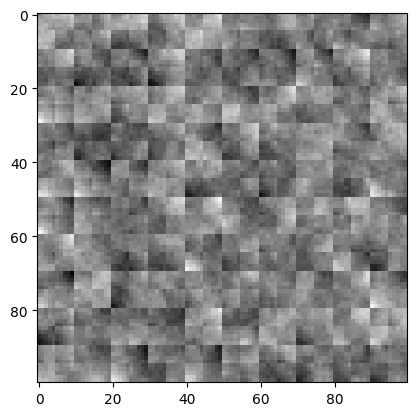

In [12]:
import matplotlib.pyplot as plt

size = 100
noise_map = [[perlin_octaves([x*0.1, y*0.1]) for x in range(size)] for y in range(size)]
plt.imshow(noise_map, cmap='gray')
plt.show()